# Black Friday Sales Data Analysis
## Part 1: Dataset Walkthrough, Column Analysis & Gender Analysis

Black Friday is known for deep discounts and special deals across electronics, home goods, clothing, and more. This notebook covers the first three steps of the analysis:

1. Walkthrough of the dataset
2. Analyzing columns
3. Analyzing the Gender column

## 1. Walkthrough of the Dataset

Load the dataset, inspect its structure, and check for missing values.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('BlackFriday.csv')

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
# Basic overview of column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  str    
 2   Gender                      537577 non-null  str    
 3   Age                         537577 non-null  str    
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  str    
 6   Stay_In_Current_City_Years  537577 non-null  str    
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 49.2 MB


In [5]:
# Number of rows and columns
df.shape

(537577, 12)

In [6]:
# Check for missing values
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

`Product_Category_2` and `Product_Category_3` are too sparse (many missing values) to be useful for this analysis, so we drop them.

In [7]:
del df['Product_Category_2']
del df['Product_Category_3']

In [8]:
# Confirm no more missing values
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Purchase                      0
dtype: int64

In [9]:
df.shape

(537577, 10)

## 2. Analyzing Columns

Dive into each column to understand its distribution and relevance, using `unique()` and `nunique()` to explore the data.

In [10]:
# Total number of unique users
df['User_ID'].nunique()

5891

In [11]:
# All the unique user IDs
df['User_ID'].unique()

array([1000001, 1000002, 1000003, ..., 1004113, 1005391, 1001529],
      shape=(5891,))

In [12]:
# Total number of unique products
df['Product_ID'].nunique()

3623

In [13]:
# All unique genders
df['Gender'].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [14]:
# All age groups
df['Age'].unique()

<StringArray>
['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']
Length: 7, dtype: str

In [15]:
# Unique occupation codes
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [16]:
# Unique city categories
df['City_Category'].unique()

<StringArray>
['A', 'C', 'B']
Length: 3, dtype: str

In [17]:
# Number of years customers have stayed in their current city
df['Stay_In_Current_City_Years'].unique()

<StringArray>
['2', '4+', '3', '1', '0']
Length: 5, dtype: str

In [18]:
# Marital status (0 = unmarried, 1 = married)
df['Marital_Status'].unique()

array([0, 1])

In [19]:
# Unique product categories
df['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [20]:
# Total amount of money spent by customers on Black Friday
df['Purchase'].sum()

np.int64(5017668378)

In [21]:
# Print the number of unique values for every column at once
for column in df.columns:
    print(column, ":", df[column].nunique())

User_ID : 5891
Product_ID : 3623
Gender : 2
Age : 7
Occupation : 21
City_Category : 3
Stay_In_Current_City_Years : 5
Marital_Status : 2
Product_Category_1 : 18
Purchase : 17959


## 3. Analyzing the Gender Column

Examine the gender distribution of customers and look for purchasing trends by gender.

In [22]:
# The number of transactions made by males and females
Male_count = len(df[df['Gender'] == 'M'])
Female_count = len(df[df['Gender'] == 'F'])

print("The male count is", Male_count, "and the female count is", Female_count)

The male count is 405380 and the female count is 132197


/tmp/ipykernel_529/2134407053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(x=labels, y=counts, palette=['skyblue', 'lightpink'])


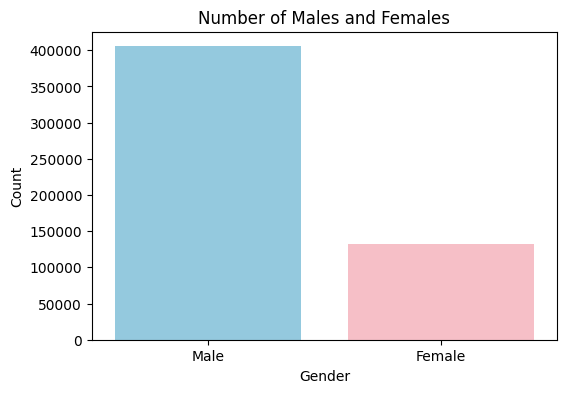

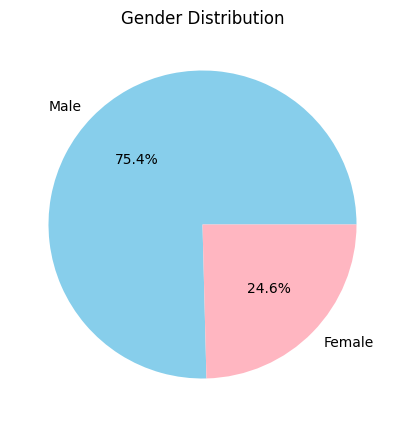

In [23]:
# Visualizing the gender split with a bar chart and a pie chart
labels = ['Male', 'Female']
counts = [Male_count, Female_count]

plt.figure(figsize=(6,4))
sea.barplot(x=labels, y=counts, palette=['skyblue', 'lightpink'])
plt.title('Number of Males and Females')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(5,5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['skyblue', 'lightpink'])
plt.title('Gender Distribution')
plt.show()

In [24]:
# A cleaner approach to counting using groupby
df.groupby('Gender').size()

Gender
F    132197
M    405380
dtype: int64

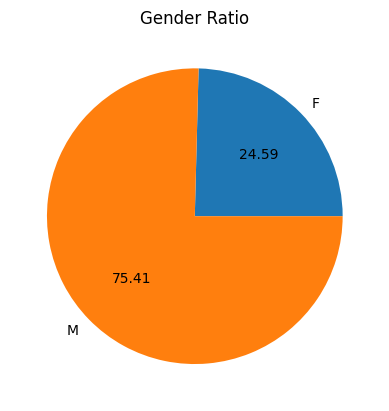

In [25]:
# Visualizing the gender ratio with groupby + plot
df.groupby('Gender').size().plot(kind='pie', autopct='%.2f', title='Gender Ratio')
plt.ylabel('')
plt.show()

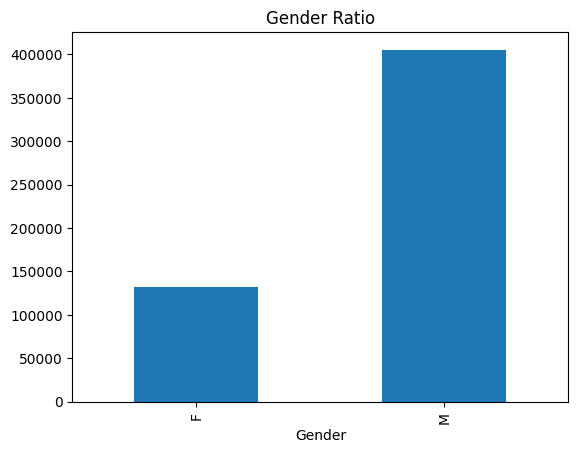

In [26]:
df.groupby('Gender').size().plot(kind='bar', title='Gender Ratio')
plt.show()

In [27]:
# Total amount spent by each gender
df.groupby('Gender').sum(numeric_only=True)['Purchase']

Gender
F    1164624021
M    3853044357
Name: Purchase, dtype: int64

In [28]:
# Average amount spent per transaction, by gender
df.groupby('Gender').mean(numeric_only=True)['Purchase']

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

**Key takeaway:** There's a significant data imbalance — male customers make up the majority of transactions and account for the largest share of total purchase value.